In [1]:
from mxlmodels import Simulator, get_ebenhoeh2014, plot
import matplotlib.pyplot as plt
from mxlpy import Simulator
import numpy as np
import pandas as pd
from mxlpy.integrators import Scipy

def bdf_integrator(rhs, y0, jacobian=None, t0=0.0):
    return Scipy(rhs=rhs, y0=y0, jacobian=jacobian, t0=t0,
                 method="BDF", atol=1e-8, rtol=1e-8)

m=get_ebenhoeh2014()
initial_variables= m.get_parameter_values()
flash_intensity = 5000.0    #uE
t_flash = 0.8               #s
dark = 1e-7                 #uE

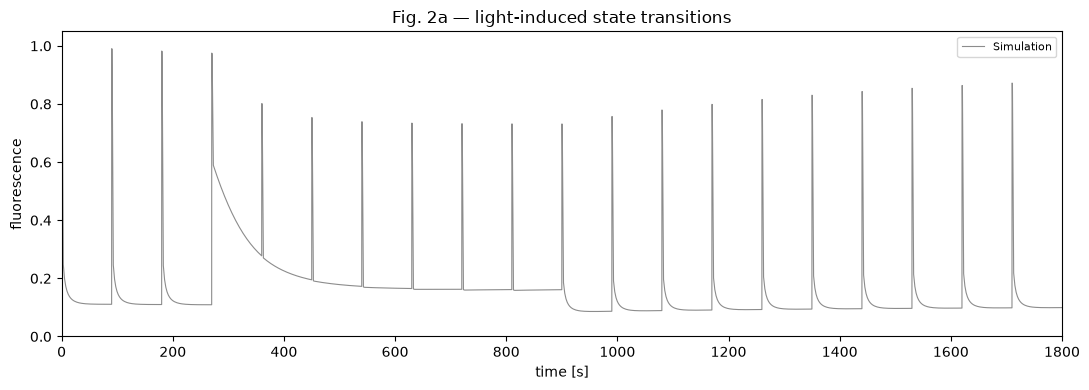

In [2]:
# figure 2a pam simulation
T_max = 1800                #s
T_on = 270                  #s
T_off = 900                 #s
dT = 90                     #s
photon = 100                #uE

sequence=[]
t=0.0
while t < T_max:
    if t%dT <= 1e-10: # flash
        sequence.append((t_flash, flash_intensity))
        t += t_flash
    else:
        dur = dT - t_flash # noflash
        intensity = photon if (T_on < t < T_off) else dark
        sequence.append((dur, intensity))
        t += dur
dur = np.array([s[0] for s in sequence])
ppfd = np.array([s[1] for s in sequence])
protocol= pd.DataFrame({"PPFD": ppfd}, index=pd.to_timedelta(np.cumsum(dur), unit="s"))

m.update_variables({
    "Plastoquinone (oxidised)" : initial_variables["PQ_tot"]/2,
    "Plastocyanine (oxidised)" : initial_variables["PC_tot"]/2,
    "Ferredoxine (oxidised)"   : initial_variables["Fd*"] / 2,
    "ATP"                      : initial_variables["A*P"] / 3,
    "NADPH"                    : initial_variables["NADP*"] / 2,
    "Light-harvesting complex" : 0.9    
})

res = (Simulator(m, integrator=bdf_integrator)
        .simulate_protocol(protocol, time_points_per_step=40)
        .get_result().unwrap_or_err().get_combined())

flou=res["Fluo"].to_numpy()
norm_flou= flou/flou.max()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(res.index, norm_flou, color="0.55", lw=0.8, label="Simulation")
ax.set(xlabel="time [s]", ylabel="fluorescence",
       title="Fig. 2a — light-induced state transitions",
       xlim=(0, T_max), ylim=(0, 1.05))
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

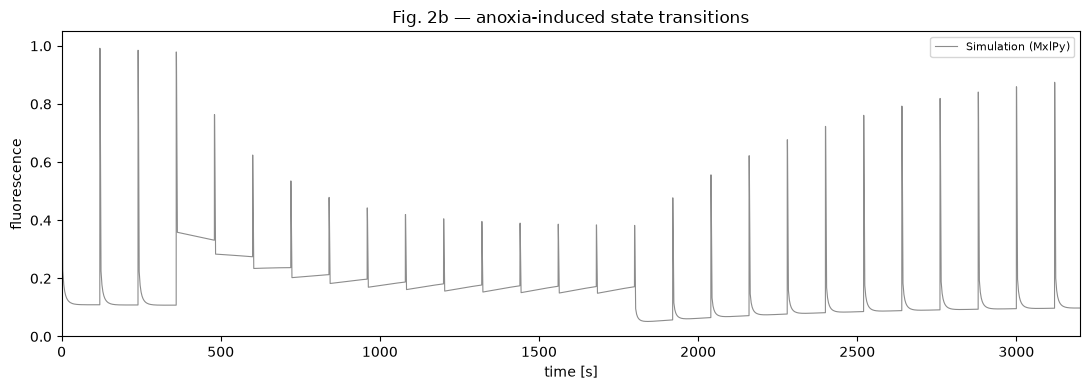

In [3]:
#anoxic state
T_max = 3200
T_on = 360 
T_off = 1800
dT = 120

O2ext = initial_variables["O2 (dissolved)_lumen"]
kNDH = initial_variables["kf_ndh"]

sequence=[]
t=0.0
while t<T_max:
    anox=T_on < t < T_off
    O2= 0.0 if anox else O2ext
    ndh= kNDH  if anox else 0.0
    if abs(t % dT) < 1e-9:
        sequence.append((t_flash,flash_intensity,O2,ndh))
        t += t_flash
    else:
        sequence.append((dT - t_flash, dark, O2, ndh))
        t += dT - t_flash
dur = np.array([s[0] for s in sequence])
intensity= [s[1] for s in  sequence]
O2= [s[2] for s in sequence]
kf_ndh=[s[3] for s in sequence]
protocol=pd.DataFrame(
    {"PPFD": intensity,
    "O2 (dissolved)_lumen": O2,
    "kf_ndh": kf_ndh},
    index=pd.to_timedelta(np.cumsum(dur), unit="s")
    )

m.update_variables({
    "Plastoquinone (oxidised)"  :  initial_variables["PQ_tot"],  
    "Plastocyanine (oxidised)"  :  0.0202,
    "Ferredoxine (oxidised)"    :  5.0,
    "ATP"                       :  0.0,
    "NADPH"                     :  0.0,
    "Light-harvesting complex"  :  0.9,
})
    
res = (Simulator(m, integrator=bdf_integrator)
        .simulate_protocol(protocol, time_points_per_step=40)
        .get_result().unwrap_or_err().get_combined())

flou=res["Fluo"].to_numpy()
norm_flou= flou/flou.max()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(res.index, norm_flou, color="0.55", lw=0.8, label="Simulation (MxlPy)")
ax.set(xlabel="time [s]", ylabel="fluorescence",
       title="Fig. 2b — anoxia-induced state transitions",
       xlim=(0, T_max), ylim=(0, 1.05))
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


  0%|          | 0/400 [00:00<?, ?it/s]

100%|██████████| 400/400 [00:38<00:00, 10.46it/s]


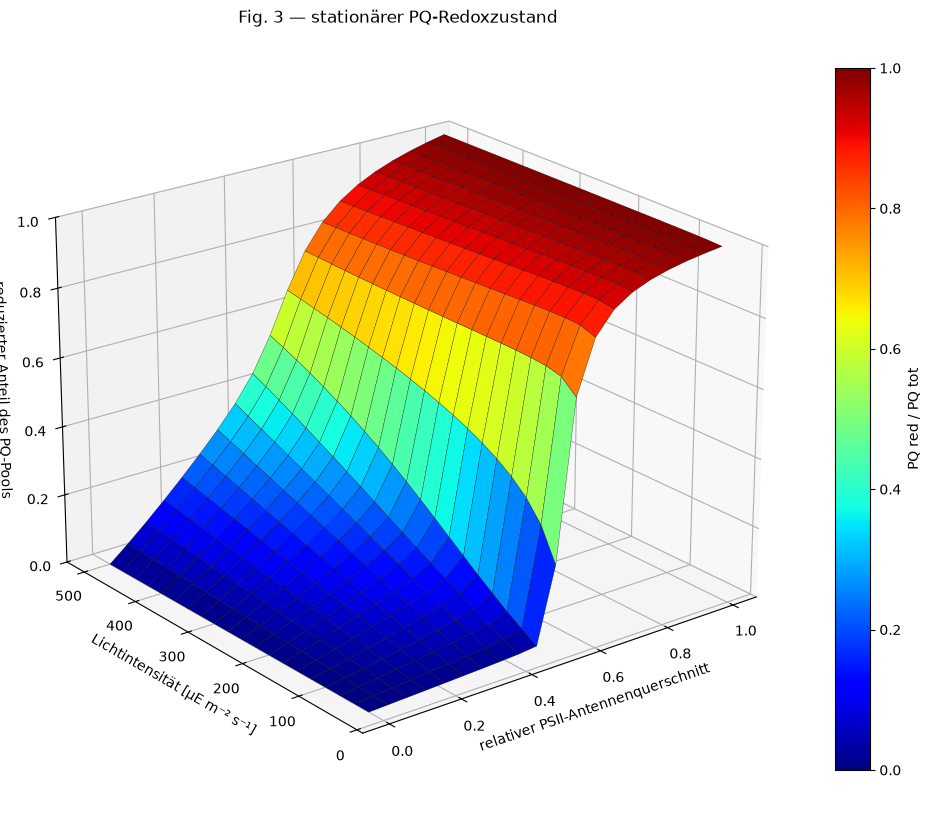

In [13]:
from mxlpy import cartesian_product, scan
from matplotlib import cm

m= get_ebenhoeh2014()
# figure 3

antenna_crosssection = np.linspace(0,1,20)
ligth_intensity = np.linspace(25, 500, 20)

grid = cartesian_product({
    "staticAntII": antenna_crosssection,                 
    "PPFD": ligth_intensity,
})

m.update_parameters({
            "staticAntI"    : 0.0,
            "kStt7"         : 0.0,             
            "kPph1"         : 0.0,
        })
m.update_variable("Light-harvesting complex", 0.0)


s= scan.steady_state(m, to_scan=grid, integrator=bdf_integrator)

reduced_PQ = (s.variables["PQ_red/tot"]
     .unstack("staticAntII")                       # Zeilen=PPFD, Spalten=staticAntII
     .reindex(index=ligth_intensity, columns=antenna_crosssection)
     .to_numpy())

fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection="3d")

X,Y=np.meshgrid(antenna_crosssection, ligth_intensity )
surf = ax.plot_surface(X, Y, reduced_PQ,  cmap=cm.jet, vmin=0, vmax=1,
                       rstride=1, cstride=1, edgecolor="k", linewidth=0.2, antialiased=True)
ax.set_xlabel("relativer PSII-Antennenquerschnitt")
ax.set_ylabel("Lichtintensität [µE m⁻² s⁻¹]")
ax.set_zlabel("reduzierter Anteil des PQ-Pools")
ax.set_title("Fig. 3 — stationärer PQ-Redoxzustand")
ax.set_zlim(0, 1)
ax.view_init(elev=22, azim=-128)
fig.colorbar(surf, ax=ax, shrink=0.6, label="PQ red / PQ tot")
fig.tight_layout()
plt.show()     

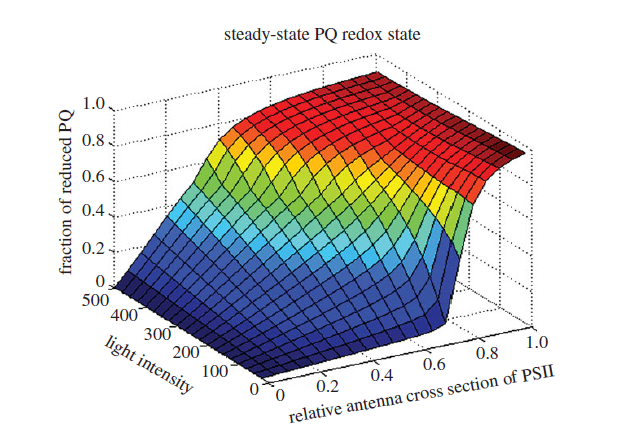

100%|██████████| 400/400 [00:53<00:00,  7.49it/s]


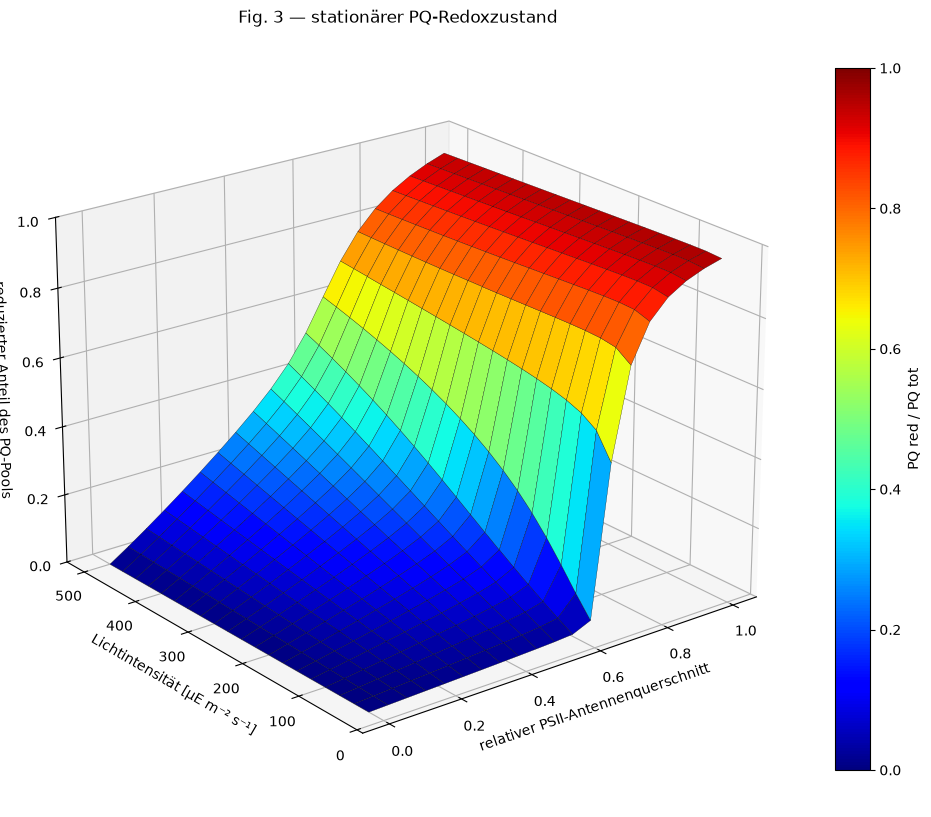

In [16]:
cross_sections = np.linspace(0, 1, 20)        # = LHC-Werte (x-Achse)
light_levels   = np.linspace(25, 500, 20)

m = get_ebenhoeh2014()
# staticAntI bleibt beim Default 0.2 -- NICHT auf 0 setzen!
m.update_parameters({
    "kStt7": 0.0,                              # State transitions einfrieren
    "kPph1": 0.0,
})
# staticAntII bleibt 0 (Default)

grid = cartesian_product({
    "Light-harvesting complex": cross_sections,   # LHC fest vorgeben, das ist die x-Achse
    "PPFD": light_levels,
})

ss = scan.steady_state(m, to_scan=grid, integrator=bdf_integrator)

reduced_PQ = (ss.variables["PQ_red/tot"]
     .unstack("Light-harvesting complex")
     .reindex(index=light_levels, columns=cross_sections)
     .to_numpy())

fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(111, projection="3d")

X,Y=np.meshgrid(antenna_crosssection, ligth_intensity)
surf = ax.plot_surface(X, Y, reduced_PQ,  cmap=cm.jet, vmin=0, vmax=1,
                       rstride=1, cstride=1, edgecolor="k", linewidth=0.2, antialiased=True)
ax.set_xlabel("relativer PSII-Antennenquerschnitt")
ax.set_ylabel("Lichtintensität [µE m⁻² s⁻¹]")
ax.set_zlabel("reduzierter Anteil des PQ-Pools")
ax.set_title("Fig. 3 — stationärer PQ-Redoxzustand")
ax.set_zlim(0, 1)
ax.view_init(elev=22, azim=-128)
fig.colorbar(surf, ax=ax, shrink=0.6, label="PQ red / PQ tot")
fig.tight_layout()
plt.show()  

schreiben an Oliver Ebenhöh falls das nicht klappt